## 2/3 ef calibration - OP9500_read

ef_freq =  

ef_pi_amp = 0.875


T1 = 20e-6

In [1]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
import lmfit

import sklearn
from sklearn.decomposition import PCA

In [2]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

In [3]:
def Rabi(delay, amp, phi0, detun, const):
    return - amp * np.cos(2*np.pi*detun*delay+phi0) + const

amp

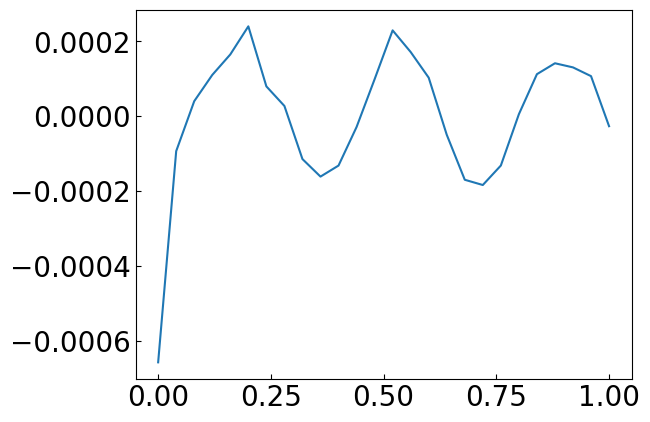

In [28]:
header = "D:/K_sunada/result/CDK173"
ef = "/2025-02-07/2025-02-07T172914_9d2c171e-d0_ef_pi_amp"
dd_ef = datadict_from_hdf5(header + ef +"/data")

Rabi_ef = dd_ef['s11']['values']
amp_ef = dd_ef['amplitude']['values']
I = (Rabi_ef.real)
Q = (Rabi_ef.imag)
PCAef = PCA_transform(I, Q)

y = PCAef[0]
x = amp_ef
plt.plot(x, y)
plt.show()

In [29]:
par_ini= {'amp': 0.0002,'phi0':0,'detun':1/0.4,'const':0}
par_min = {'amp': 0,'phi0':-2*np.pi,'detun':-np.inf,'const':-np.inf}
par_max = {'amp': np.inf,'phi0':2*np.pi,'detun':np.inf,'const':np.inf,}
par_vary = {'amp': True,'phi0':True,'detun':True,'const':True}

model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(value = par_ini[name],min = par_min[name],max = par_max[name],vary = par_vary[name])

result_ef = model.fit(data = y, params = params, delay = x)
result_ef 

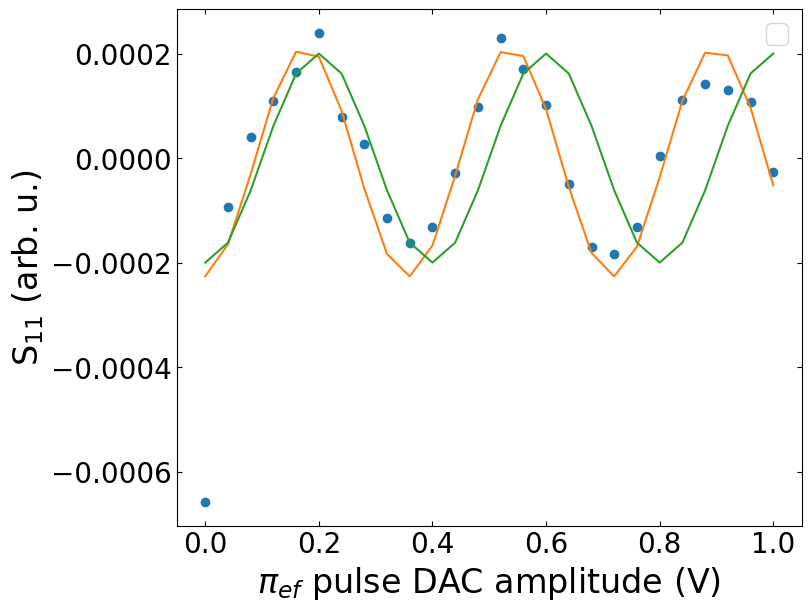

In [30]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
# plt.title("Rabi(amp)")
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_ef.plot_fit(ax = ax)
plt.plot(amp_ef,result_ef.init_fit)

plt.title("")
plt.legend("")
ax.set_xlabel('$\pi_{ef}$ pulse DAC amplitude (V)', size='large')
ax.set_ylabel('S$_{11}$ (arb. u.)', size='large')
# # ax.set_ylim(-40, 40)
# ax.set_xlim(0, 1.)
# plt.savefig('ef_rabi.png', bbox_inches='tight')
plt.show()

In [31]:
np.pi/(2.77100088*2*np.pi)*5

0.9022010848296808

ramsey

In [20]:
pl = "/2025-02-07/2025-02-07T172728_5e324341-d2_ef_T2r1d"
mi = "/2025-02-07/2025-02-07T172754_6d5fbb5b-d2_ef_T2r1d"
dd_pl = datadict_from_hdf5(header + pl +"/data")
dd_mi = datadict_from_hdf5(header + mi +"/data")

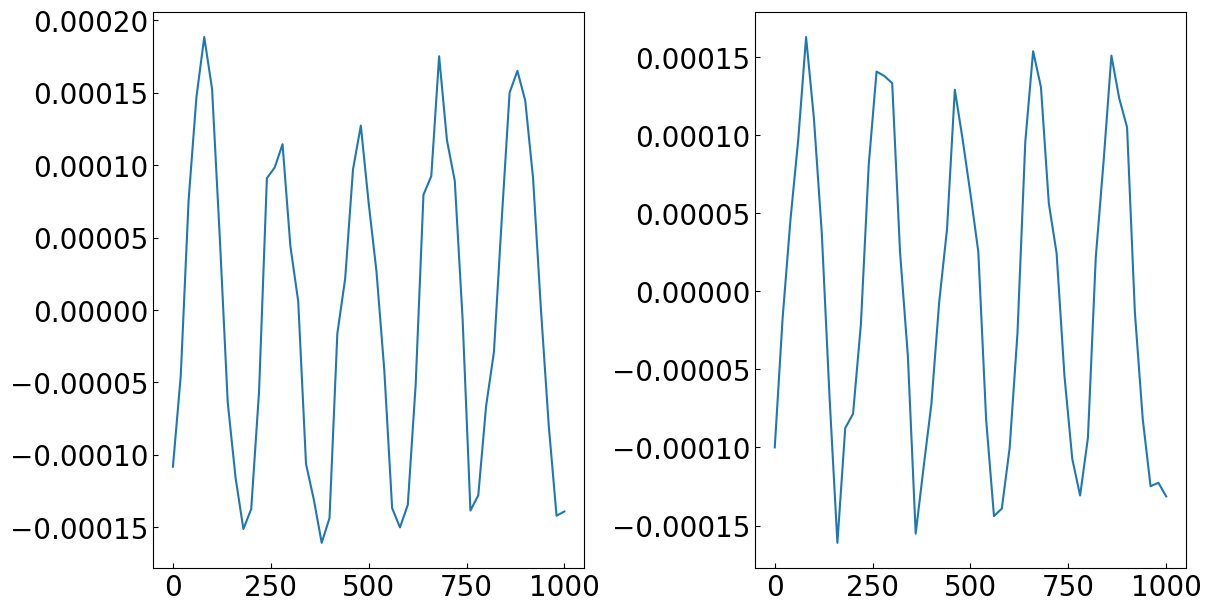

In [21]:
Rabi_pl = dd_pl['s11']['values']
delay_pl = dd_pl['delay']['values']
Rabi_mi = dd_mi['s11']['values']
delay_mi = dd_mi['delay']['values']

I_pl = (Rabi_pl.real)
Q_pl = (Rabi_pl.imag)
I_mi = (Rabi_mi.real)
Q_mi = (Rabi_mi.imag)

PCA_pl = PCA_transform(I_pl, Q_pl)
y_pl = PCA_pl[0]
x_pl = delay_pl

PCA_mi = PCA_transform(I_mi, Q_mi)
y_mi = PCA_mi[0]
x_mi = delay_mi

fig, ax = plt.subplots(1,2,figsize=(12,6),constrained_layout=True)
ax[0].plot(x_pl, y_pl)
ax[1].plot(x_mi, y_mi)
plt.show()

In [22]:
par_ini_pl = {'amp': 0.00015,'phi0':0,'detun':1/200,'const':0.00001}
par_ini_mi = {'amp': 0.00015,'phi0':0,'detun':1/200,'const':0.00001}
par_min = {'amp': 0,'phi0':-2*np.pi,'detun':-np.inf,'const':0}
par_max = {'amp': np.inf,'phi0':2*np.pi,'detun':np.inf,'const':np.inf,}
par_vary = {'amp': True,'phi0':True,'detun':True,'const':True}

model = lmfit.Model(Rabi)

In [23]:
params_pl = model.make_params()
for name in model.param_names:
    params_pl[name].set(value = par_ini_pl[name],min = par_min[name],max = par_max[name],vary = par_vary[name])
    
result_pl = model.fit(data = y_pl, params = params_pl, delay = x_pl)
result_pl


In [25]:
params_mi = model.make_params()
for name in model.param_names:
    params_mi[name].set(value = par_ini_mi[name],min = par_min[name],max = par_max[name],vary = par_vary[name])
    
result_mi = model.fit(data = y_mi, params = params_mi, delay = x_mi)
result_mi

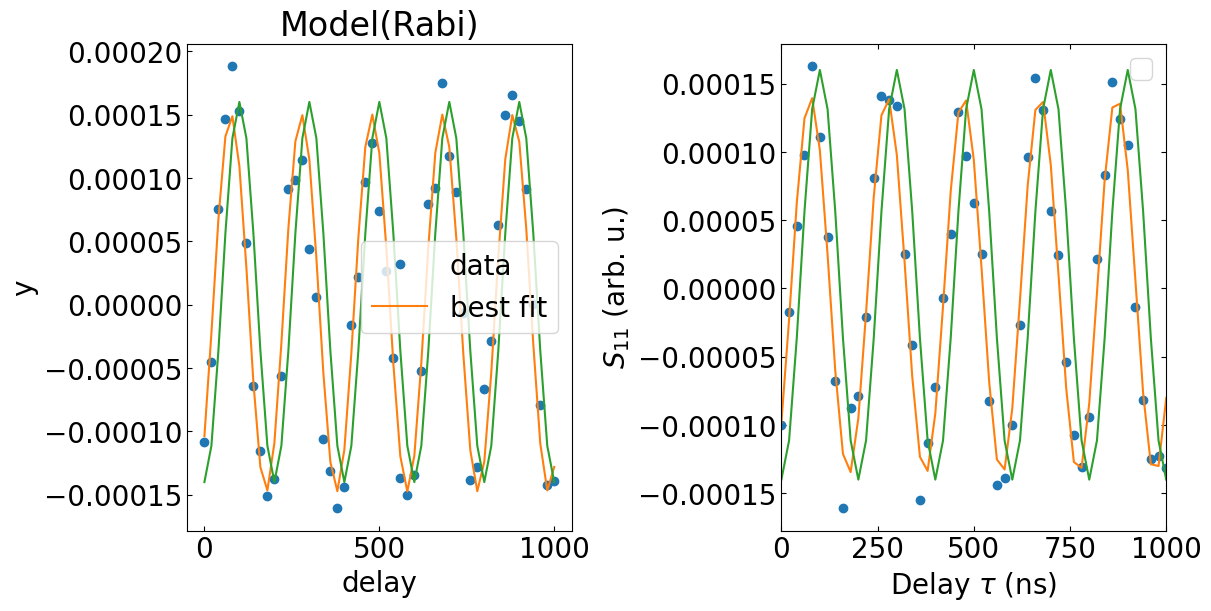

In [26]:
fig, ax = plt.subplots(1,2,figsize=(12,6),constrained_layout=True)
plt.rcParams["font.size"] = 20

plt.tick_params(top='on',bottom='on',left='on',right='on',)

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_pl.plot_fit(ax = ax[0])
ax[0].plot(x_pl,result_pl.init_fit)
result_mi.plot_fit(ax = ax[1])
ax[1].plot(x_mi,result_mi.init_fit)

plt.title("")
plt.legend("")
plt.xlabel(r"Delay ${\tau}$ (ns)")
plt.ylabel("$S_{11}$ (arb. u.)")
plt.xlim(0, 1000)
# plt.savefig('ef_ramsey_exp.png', bbox_inches='tight')
plt.show()

In [27]:
detun = ((0.005-0.00495707)+ (0.00502784-0.005))/2 #GHz
detun

3.538499999999976e-05

drag

In [32]:
drag = "/2025-02-07/2025-02-07T173038_cf80a618-d1_ef_pi_drag" #n=7
dd_drag = datadict_from_hdf5(header + drag +"/data")

drag1 = "/2025-02-07/2025-02-07T173115_e5068ded-d1_ef_pi_drag" #n=11
dd_drag1 = datadict_from_hdf5(header + drag1 +"/data")

drag2 = "/2025-02-07/2025-02-07T173151_fa9045ee-d1_ef_pi_drag" #n=17
dd_drag2 = datadict_from_hdf5(header + drag2 +"/data")

In [33]:
Rabi_drag = dd_drag['s11']['values']
drag = dd_drag['beta']['values']
I_drag = (Rabi_drag.real)
Q_drag = (Rabi_drag.imag)

Rabi_drag1 = dd_drag1['s11']['values']
drag1 = dd_drag1['beta']['values']
I_drag1 = (Rabi_drag1.real)
Q_drag1 = (Rabi_drag1.imag)

Rabi_drag2 = dd_drag2['s11']['values']
drag2 = dd_drag2['beta']['values']
I_drag2 = (Rabi_drag2.real)
Q_drag2 = (Rabi_drag2.imag)

In [34]:
def PCA_transform1(Re_c_amp, Im_c_amp, Re_c_drag, Im_c_drag):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c_amp]).T, np.array([Im_c_amp]).T], axis = 1)
    c1_data = np.concatenate([np.array([Re_c_drag]).T, np.array([Im_c_drag]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    
    c1_pca = pca.transform(c1_data)
    c1_PCA1 = c1_pca.T[0]
    c1_PCA2 = c1_pca.T[1]
    return c_PCA1, c_PCA2, c1_PCA1, c1_PCA2,

In [35]:
PCA_drag = PCA_transform1(I_drag, Q_drag, I_drag, Q_drag)
y = PCA_drag[0]
y0 = PCA_drag[2]
x0 = drag

PCA_drag1 = PCA_transform1(I_drag, Q_drag, I_drag1, Q_drag1)
y1 = PCA_drag1[2]
x1 = drag1

PCA_drag2 = PCA_transform1(I_drag, Q_drag, I_drag2, Q_drag2)
y2 = PCA_drag2[2]
x2 = drag2

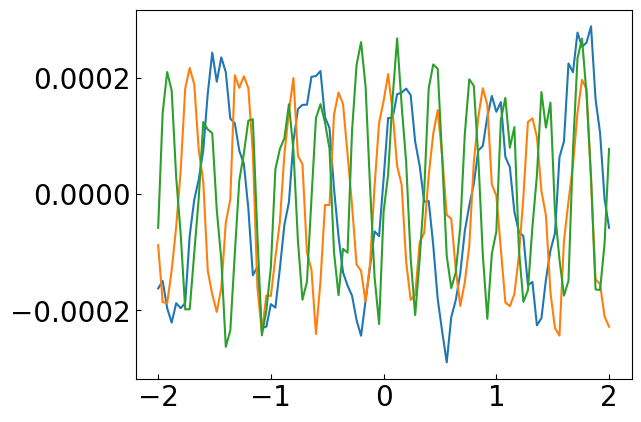

In [36]:
plt.plot(x0, y0)
plt.plot(x1, y1)
plt.plot(x2, y2)
plt.show()

In [57]:
par_ini= {'amp': 0.0002,'phi0':np.pi/2,'detun':1/0.3,'const':0}
par_min = {'amp': 0,'phi0':-2*np.pi,'detun':-np.inf,'const':-np.pi}
par_max = {'amp': np.inf,'phi0':2*np.pi,'detun':np.inf,'const':np.inf,}
par_vary = {'amp': True,'phi0':True,'detun':True,'const':True}
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
    
result0 = model.fit(data = y0, params = params, delay = x0)
result1 = model.fit(data = y1, params = params, delay = x1)
result2 = model.fit(data = y2, params = params, delay = x2)

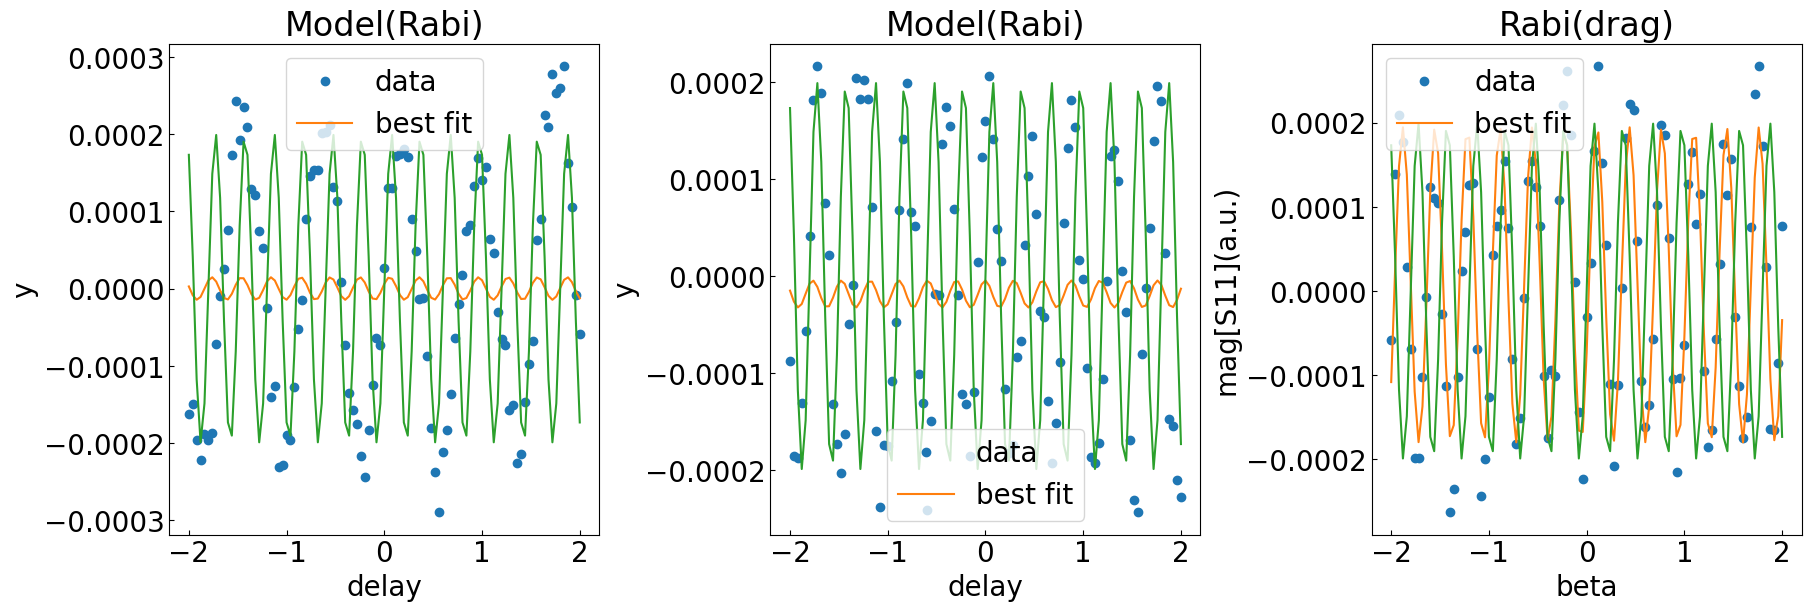

In [58]:
fig, ax = plt.subplots(1,3,figsize=(18,6),constrained_layout=True)
plt.title("Rabi(drag)")
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result0.plot_fit(ax = ax[0])
ax[0].plot(x0,result0.init_fit)
result1.plot_fit(ax = ax[1])
ax[1].plot(x1,result1.init_fit)
result2.plot_fit(ax = ax[2])
ax[2].plot(x2,result2.init_fit)
plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")
plt.show()

In [41]:
result0

In [42]:
res0 = (-2*np.pi-1.88279284)/(2*np.pi*1.24543740)
res0

-1.0435336110060838

In [47]:
result1

In [48]:
res1 = (-4*np.pi-2.68523764)/(2*np.pi*2.31742150)
res1

-1.0474438265902062

In [59]:
result2

In [60]:
res2 = (-6*np.pi-1.12572460)/(2*np.pi*3.01746840)
res2

-1.053586720129413

In [61]:
beta = (res0 + res1 + res2)/3
beta

-1.0481880525752343

half drag

In [62]:
drag = "/2025-02-07/2025-02-07T173233_13bf5324-d1_ef_half_pi_drag" #n=7
dd_drag = datadict_from_hdf5(header + drag +"/data")

drag1 = "/2025-02-07/2025-02-07T173322_30e4c304-d1_ef_half_pi_drag" #n=13
dd_drag1 = datadict_from_hdf5(header + drag1 +"/data")

drag2 = "/2025-02-07/2025-02-07T173404_49feed15-d1_ef_half_pi_drag" #n=17
dd_drag2 = datadict_from_hdf5(header + drag2 +"/data")

In [63]:
Rabi_drag = dd_drag['s11']['values']
drag = dd_drag['beta']['values']
I_drag = (Rabi_drag.real)
Q_drag = (Rabi_drag.imag)

Rabi_drag1 = dd_drag1['s11']['values']
drag1 = dd_drag1['beta']['values']
I_drag1 = (Rabi_drag1.real)
Q_drag1 = (Rabi_drag1.imag)

Rabi_drag2 = dd_drag2['s11']['values']
drag2 = dd_drag2['beta']['values']
I_drag2 = (Rabi_drag2.real)
Q_drag2 = (Rabi_drag2.imag)

In [64]:
PCA_drag = PCA_transform1(I_drag, Q_drag, I_drag, Q_drag)
y = PCA_drag[0]
y0 = PCA_drag[2]
x0 = drag

PCA_drag1 = PCA_transform1(I_drag, Q_drag, I_drag1, Q_drag1)
y1 = PCA_drag1[2]
x1 = drag1

PCA_drag2 = PCA_transform1(I_drag, Q_drag, I_drag2, Q_drag2)
y2 = PCA_drag2[2]
x2 = drag2

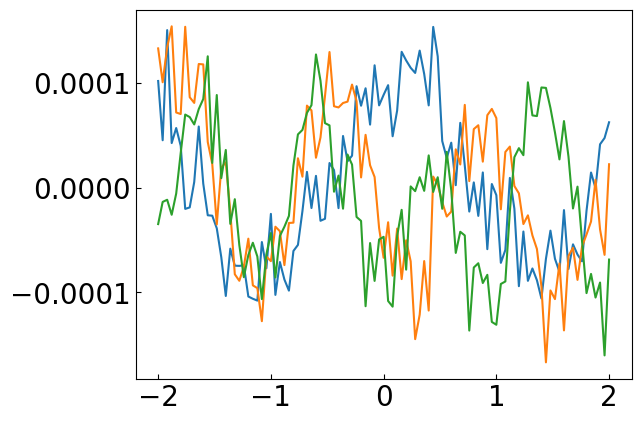

In [65]:
plt.plot(x0, y0)
plt.plot(x1, y1)
plt.plot(x2, y2)
plt.show()

In [76]:
par_ini= {'amp': 0.0001,'phi0':np.pi,'detun':1/1.2,'const':0}
par_min = {'amp': 0,'phi0':-2*np.pi,'detun':-np.inf,'const':-np.pi}
par_max = {'amp': np.inf,'phi0':2*np.pi,'detun':np.inf,'const':np.inf,}
par_vary = {'amp': True,'phi0':True,'detun':True,'const':True}
model = lmfit.Model(Rabi)

model = lmfit.Model(Rabi)
params = model.make_params()
for name in model.param_names:
    params[name].set(value = par_ini[name],min = par_min[name],max = par_max[name],vary = par_vary[name])
    
result0 = model.fit(data = y0, params = params, delay = x0)
result1 = model.fit(data = y1, params = params, delay = x1)
result2 = model.fit(data = y2, params = params, delay = x2)

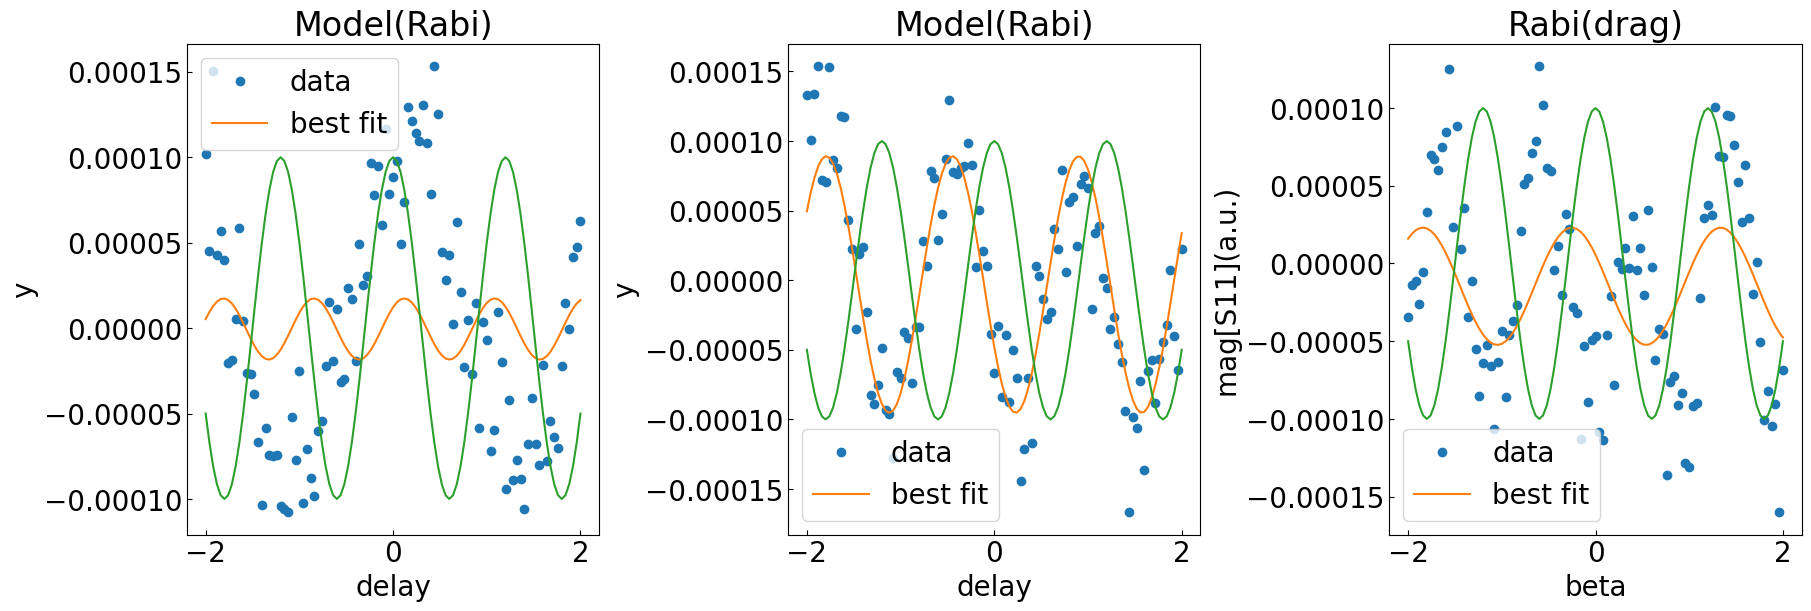

In [77]:
fig, ax = plt.subplots(1,3,figsize=(18,6),constrained_layout=True)
plt.title("Rabi(drag)")
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result0.plot_fit(ax = ax[0])
ax[0].plot(x0,result0.init_fit)
result1.plot_fit(ax = ax[1])
ax[1].plot(x1,result1.init_fit)
result2.plot_fit(ax = ax[2])
ax[2].plot(x2,result2.init_fit)
plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")
plt.show()

In [68]:
result0

In [69]:
res0 = (-2.78545613)/(2*np.pi*0.41084073)
res0

-1.0790534615570395

In [78]:
result1

In [80]:
res1 = (-5.22148380)/(2*np.pi*0.74223709)
res1

-1.1196219755661272

In [72]:
result2

In [73]:
res2 = (-2*np.pi-0.57607519)/(2*np.pi*0.98817710)
res2

-1.1047465217328987

In [81]:
(res0+res1+res2)/3

-1.1011406529520218

T1

In [100]:
def Dephase(delay, amp, gamma, const):
    return amp*np.exp(-gamma*delay) + const

t1 ="/2025-02-03/2025-02-03T145241_14e61950-d3_ef_T1"

dd_t1 = datadict_from_hdf5(header + t1 +"/data")

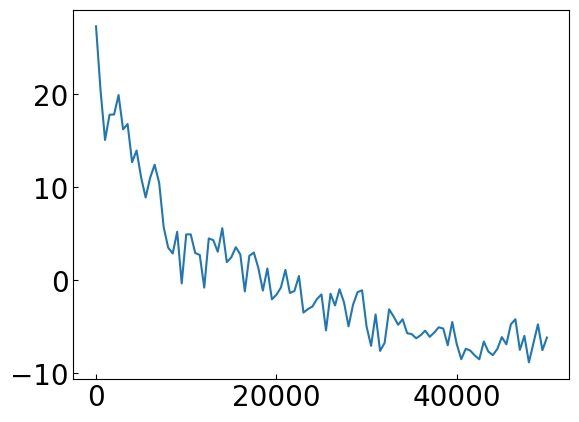

In [101]:
s11_t1 = dd_t1['s11']['values']
delay_t1 = dd_t1['delay']['values']
I_t1 = (s11_t1.real)
Q_t1 = (s11_t1.imag)
PCA_t1 = PCA_transform(I_t1, Q_t1)

y_t1 = PCA_t1[0]
x_t1 = delay_t1

plt.plot(x_t1, y_t1)
plt.show()

In [102]:
par_ini_t1 = {'gamma': 1/40000e-3,'amp':30,'const':-2.4}
par_min_t1 = {'gamma': 0,'amp':0,'const':-np.inf}
par_max_t1 = {'gamma': np.inf,'amp':np.inf,'const':np.inf,}
par_vary_t1 = {'gamma': True,'amp':True,'const':True}

model = lmfit.Model(Dephase)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_t1[name],
    min = par_min_t1[name],
    max = par_max_t1[name],
    vary = par_vary_t1[name]
    )
result_t1 = model.fit(data = y_t1, params = params, delay = x_t1*1e-3)
result_t1

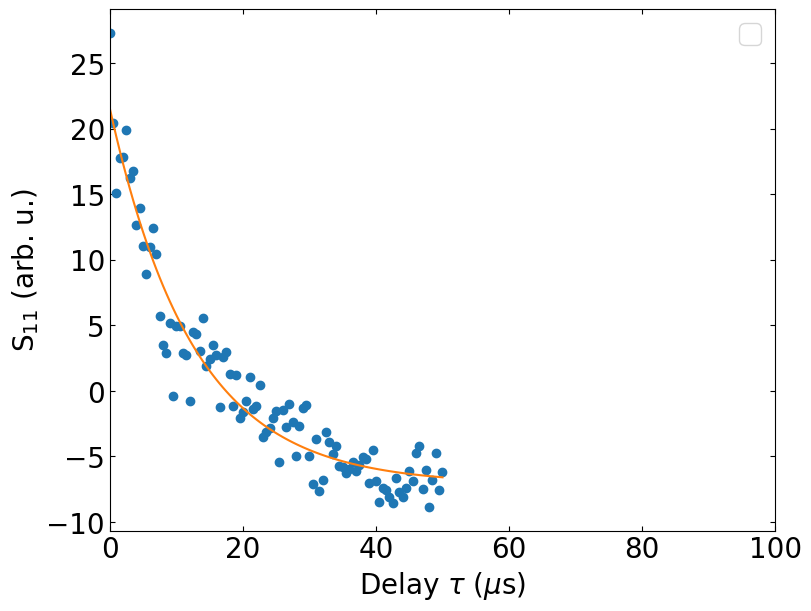

In [103]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20

plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_t1.plot_fit(ax = ax)
# plt.plot(delay_t1,result_t1.init_fit)

plt.title("")
plt.legend("")
ax.set_xlabel(r'Delay $\tau$ ($\mu$s)')#, size='large')
ax.set_ylabel('S$_{11}$ (arb. u.)')
ax.set_xlim(0, 100)
# plt.savefig('ef_T1.png', bbox_inches='tight')

plt.show()

In [104]:
T1 = (1/0.07983110)*1e-9
T1

1.2526446460088864e-08